In [53]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [54]:
# Load your CSV
df = pd.read_csv("detection_accuracy.csv")

In [55]:
# Fill NaN with 0 and ensure integers
df = df.fillna(0).astype(int)

In [56]:
# Define classes
classes = ['crownrot', 'fruitfasci', 'fruitrot', 'healthy', 'mealy', 'multicrown', 'rootrot']

In [57]:
# Display names for heatmaps
display_names = [
    'Crown Rot Disease', 
    'Fruit Fasciation Disorder', 
    'Fruit Rot Disease', 
    'Healthy', 
    'Mealybug Wilt Disease', 
    'Multiple Crown Disorder', 
    'Root Rot Disease'
]

In [58]:
# Initialize lists
precisions, recalls, f1s, accuracies = [], [], [], []

for c in classes:
    y_true = df[f'{c}_ground']
    y_pred = df[f'{c}_ai']
    
    precisions.append(precision_score(y_true, y_pred))
    recalls.append(recall_score(y_true, y_pred))
    f1s.append(f1_score(y_true, y_pred))
    accuracies.append(accuracy_score(y_true, y_pred))

In [62]:
# Macro average
print("Macro Precision:", sum(precisions)/len(precisions))
print("Macro Recall:", sum(recalls)/len(recalls))
print("Macro F1:", sum(f1s)/len(f1s))
print("Macro Accuracy:", sum(accuracies)/len(accuracies))

# Micro average (all labels flattened)
y_true_all = df[[f'{c}_ground' for c in classes]].values.flatten()
y_pred_all = df[[f'{c}_ai' for c in classes]].values.flatten()

print("Micro Precision:", precision_score(y_true_all, y_pred_all))
print("Micro Recall:", recall_score(y_true_all, y_pred_all))
print("Micro F1:", f1_score(y_true_all, y_pred_all))
print("Micro Accuracy:", accuracy_score(y_true_all, y_pred_all))

Macro Precision: 0.8401360544217688
Macro Recall: 0.9
Macro F1: 0.8611214182642755
Macro Accuracy: 0.9619047619047619
Micro Precision: 0.896551724137931
Micro Recall: 0.9629629629629629
Micro F1: 0.9285714285714286
Micro Accuracy: 0.9619047619047619


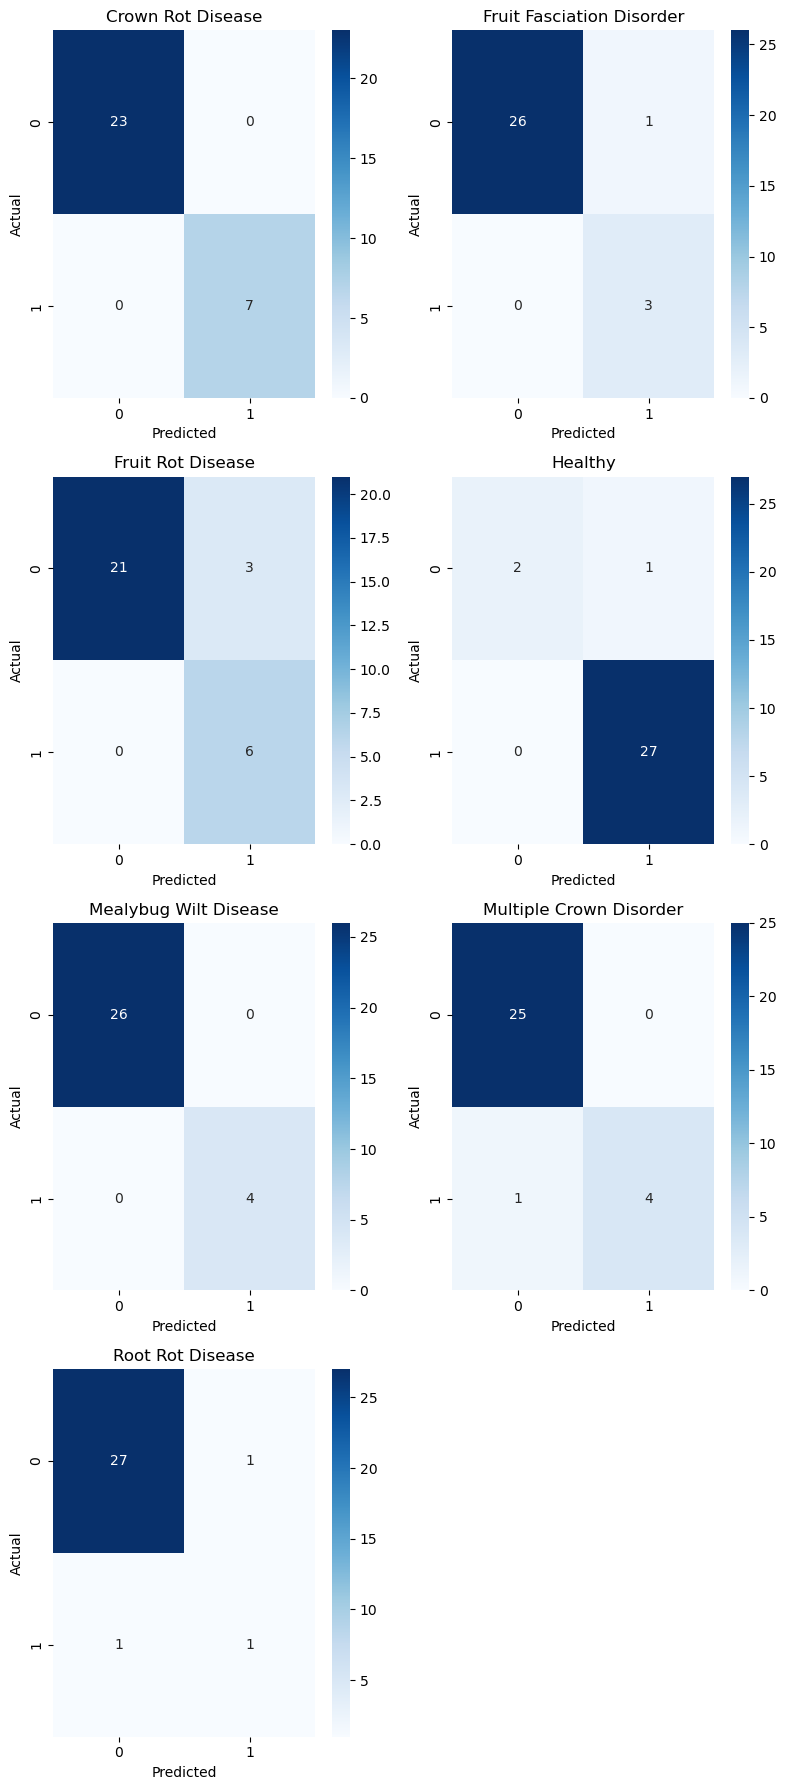

In [67]:
fig, axes = plt.subplots(4, 2, figsize=(8, 18))  # 2 rows, 4 cols
axes = axes.flatten()

for i, c in enumerate(classes):
    y_true = df[f'{c}_ground']
    y_pred = df[f'{c}_ai']
    
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(display_names[i])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Remove extra subplot if classes < grid size
if len(classes) < len(axes):
    for j in range(len(classes), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

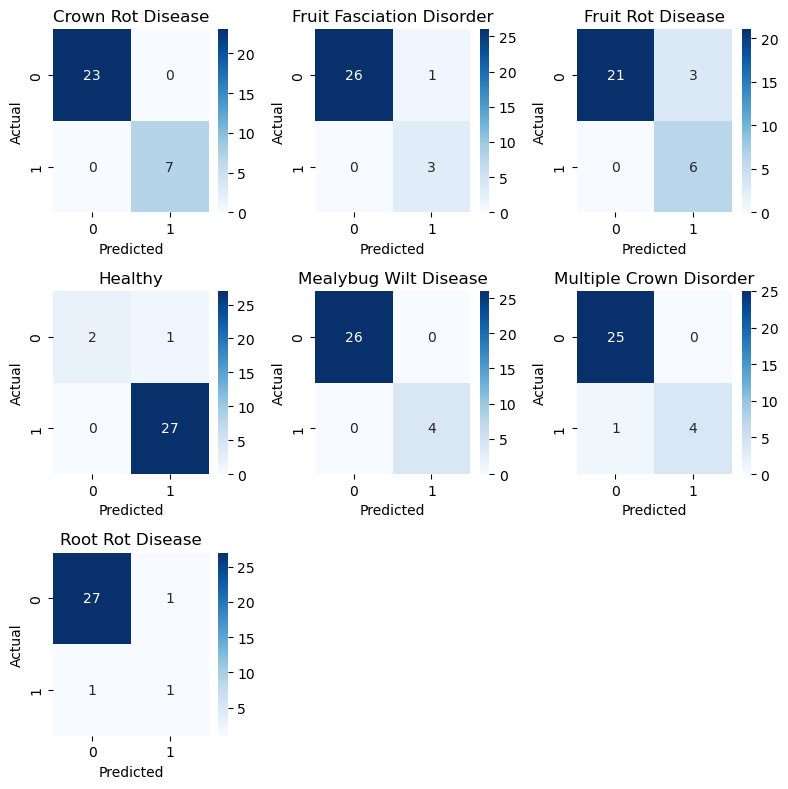

In [80]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))  # 2 rows, 4 cols
axes = axes.flatten()

for i, c in enumerate(classes):
    y_true = df[f'{c}_ground']
    y_pred = df[f'{c}_ai']
    
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(display_names[i])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Remove extra subplot if classes < grid size
if len(classes) < len(axes):
    for j in range(len(classes), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()